# House Prices Prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import dagshub
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

c:\Users\taso\ML\.venv\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [4]:
dagshub.init(repo_owner="aband22", repo_name="house-prices", mlflow=True)
mlflow.set_experiment("house-prices-experiment")
print("MLflow connected!")

Initialized MLflow to track repo "aband22/house-prices"

Repository aband22/house-prices initialized!

MLflow connected!


https://dagshub.com/aband22/house-prices.mlflow
https://dagshub.com/aband22/house-prices.mlflow/#/models/house-prices-best-model

In [5]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()
train.columns


Train shape: (1460, 81)
Test shape: (1459, 80)


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# Data Analysis

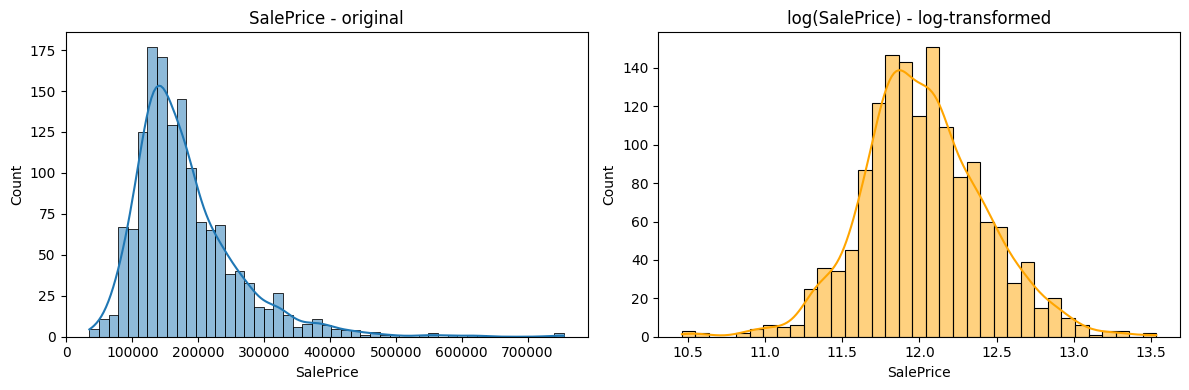

Original Skewness: 1.8829
Log Skewness:  0.1213

Conclusion: SalePrice is highly skewed (skew=1.88).
After log1p transformation, skew=0.12 — the model will learn log(SalePrice).


In [6]:
# SalePrice განაწილება
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice - original')
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='orange')
axes[1].set_title('log(SalePrice) - log-transformed')
plt.tight_layout()
plt.show()
print(f'Original Skewness: {train["SalePrice"].skew():.4f}')
print(f'Log Skewness:  {np.log1p(train["SalePrice"]).skew():.4f}')
print()
print('Conclusion: SalePrice is highly skewed (skew=1.88).')
print('After log1p transformation, skew=0.12 — the model will learn log(SalePrice).')

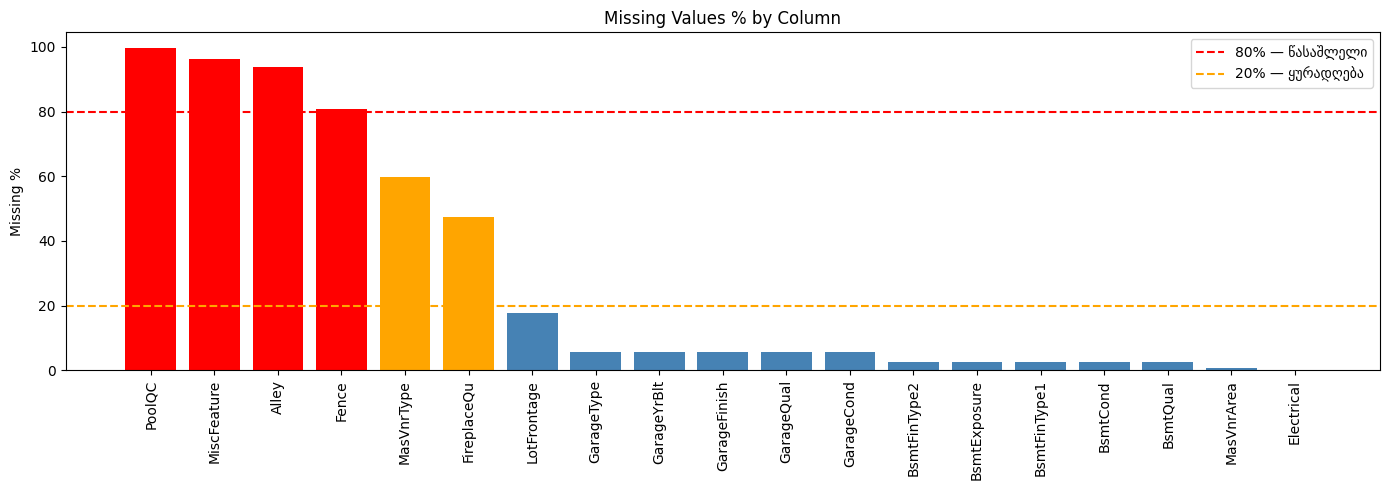

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtFinType2             38       2.60
BsmtExposure             38       2.60
BsmtFinType1             37       2.53
BsmtCond                 37       2.53
BsmtQual                 37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


In [7]:
# Missing values 
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})

plt.figure(figsize=(14, 5))
colors = ['red' if x > 80 else 'orange' if x > 20 else 'steelblue' for x in missing_pct]
plt.bar(missing_df.index, missing_df['Missing %'], color=colors)
plt.axhline(y=80, color='red', linestyle='--', label='80% — წასაშლელი')
plt.axhline(y=20, color='orange', linestyle='--', label='20% — ყურადღება')
plt.xticks(rotation=90)
plt.title('Missing Values % by Column')
plt.ylabel('Missing %')
plt.legend()
plt.tight_layout()
plt.show()
print(missing_df)

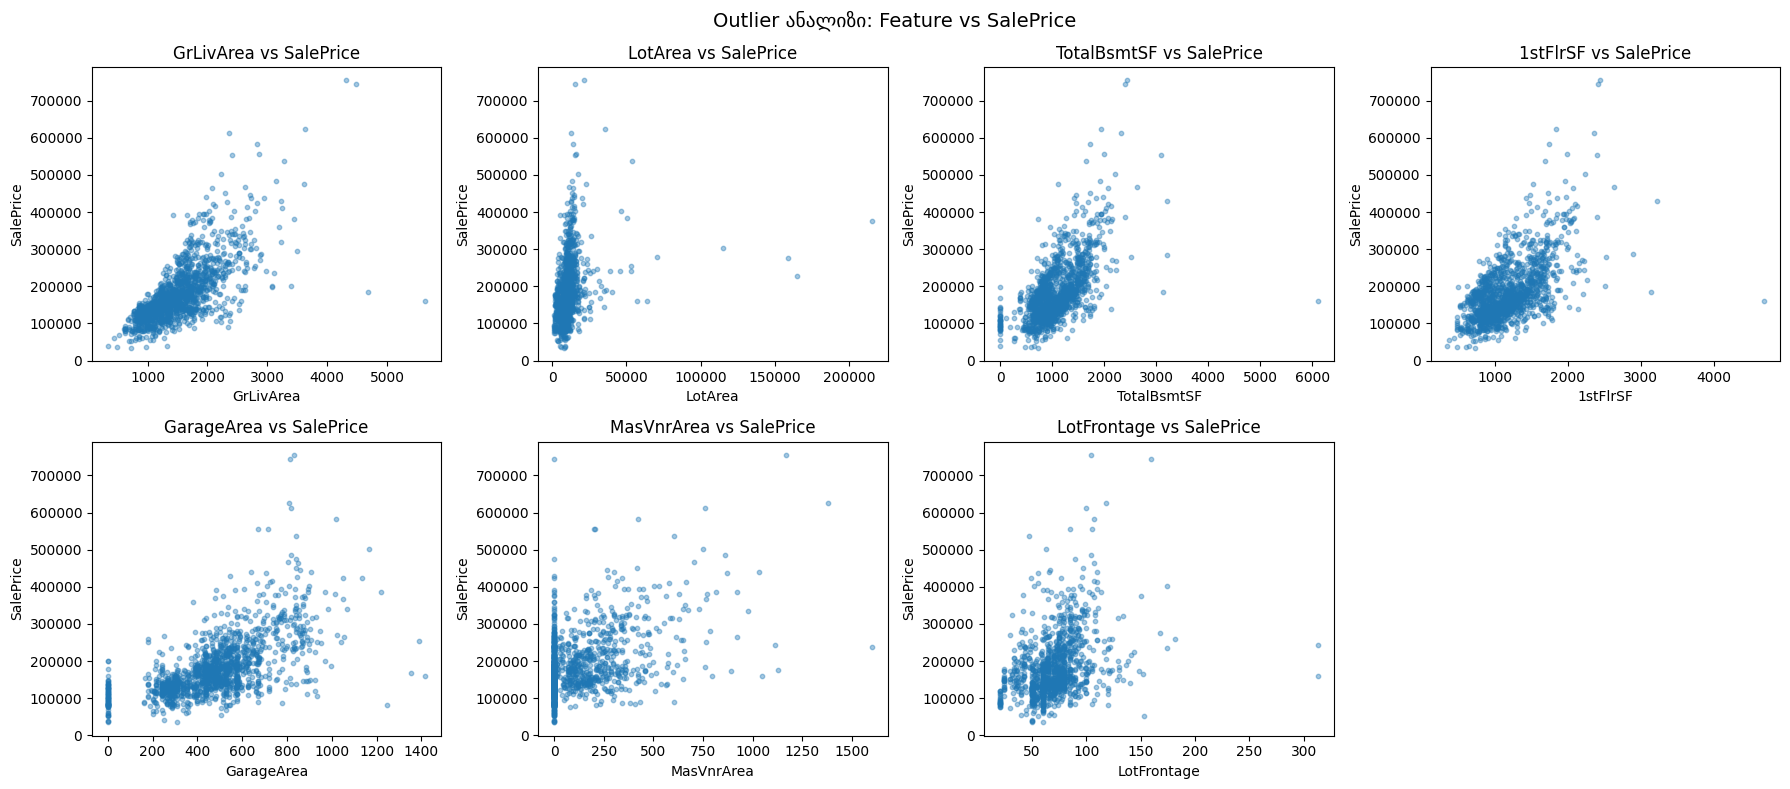

დაკვირვება:
- GrLivArea: 2 სახლი >4000 sqft მაგრამ დაბალი ფასი — outlier!
- LotArea: რამდენიმე სახლი ძალიან დიდი lot-ით — outlier!
- TotalBsmtSF: ერთი სახლი >6000 sqft — outlier!


In [8]:
# Outlier ანალიზი — Scatter plots
numeric_features = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF',
                    'GarageArea', 'MasVnrArea', 'LotFrontage']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].scatter(train[col], train['SalePrice'], alpha=0.4, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs SalePrice')
axes[-1].axis('off')
plt.suptitle('Outlier ანალიზი: Feature vs SalePrice', fontsize=14)
plt.tight_layout()
plt.show()
print('დაკვირვება:')
print('- GrLivArea: 2 სახლი >4000 sqft მაგრამ დაბალი ფასი — outlier!')
print('- LotArea: რამდენიმე სახლი ძალიან დიდი lot-ით — outlier!')
print('- TotalBsmtSF: ერთი სახლი >6000 sqft — outlier!')

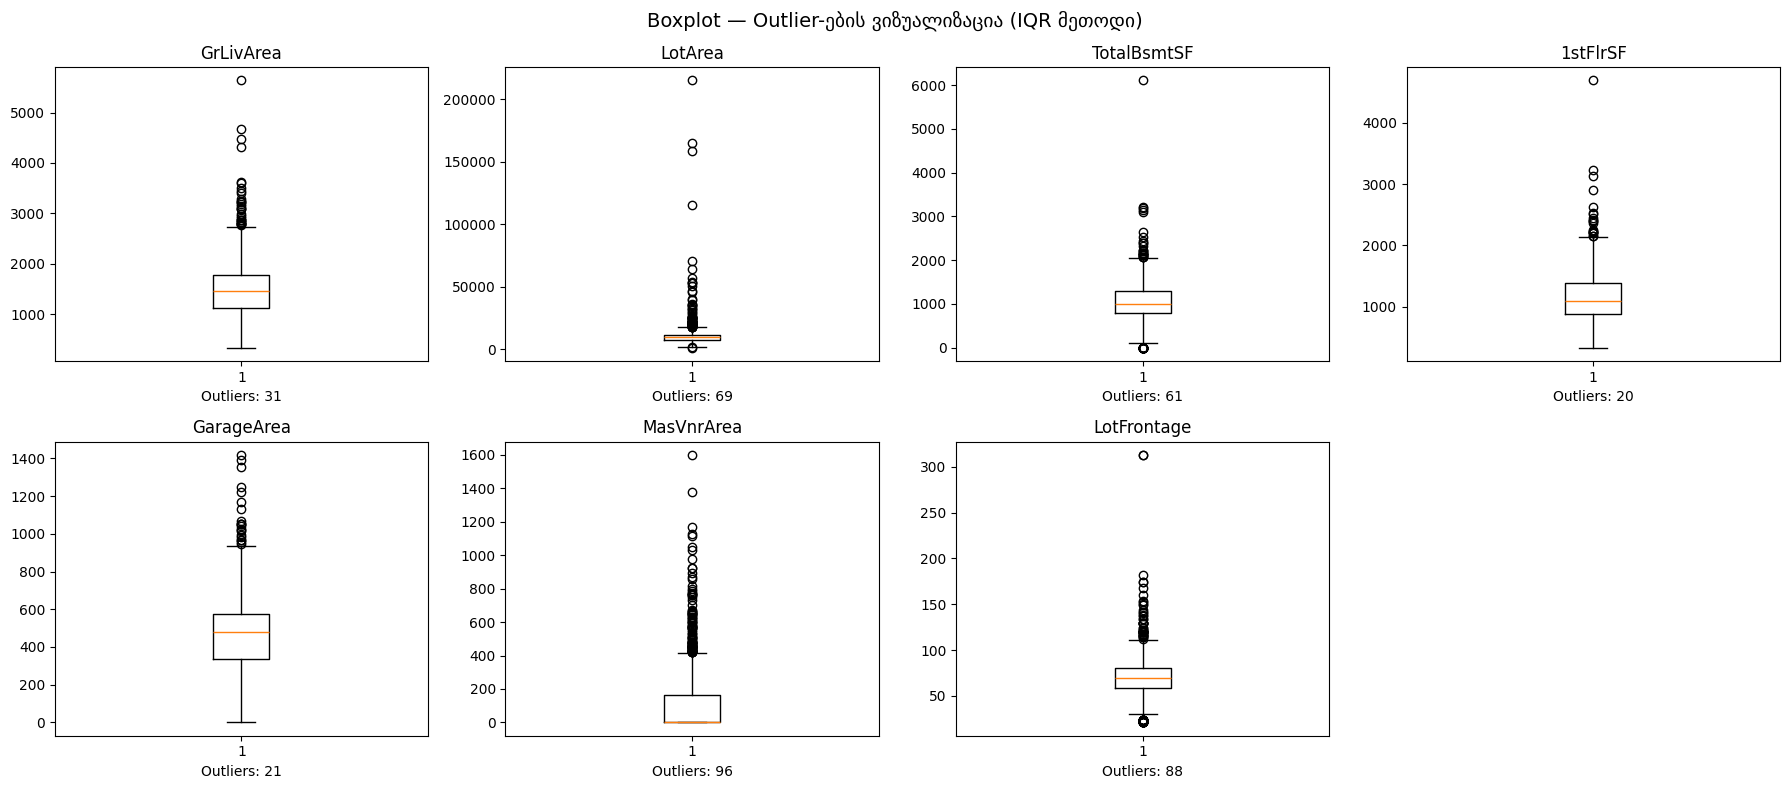

In [9]:
# Boxplot outlier ვიზუალიზაცია
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].boxplot(train[col].dropna())
    axes[i].set_title(col)
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = train[(train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)][col]
    axes[i].set_xlabel(f'Outliers: {len(outliers)}')
axes[-1].axis('off')
plt.suptitle('Boxplot — Outlier-ების ვიზუალიზაცია (IQR მეთოდი)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Mean vs Median — სად Mean ცუდი არჩევანია?
print('Mean vs Median შედარება:')
print('=' * 65)
for col in numeric_features:
    mean_val = train[col].mean()
    median_val = train[col].median()
    diff_pct = abs(mean_val - median_val) / (median_val + 1) * 100
    flag = ' <-- Mean ცუდია! Outlier-ები ამახინჯებს' if diff_pct > 15 else ''
    print(f'{col:20} Mean={mean_val:8.1f}  Median={median_val:8.1f}  diff={diff_pct:.1f}%{flag}')
print()
print('დასკვნა: outlier-იანი სვეტებში Mean ამახინჯებს სურათს.')
print('ამიტომ ყველა numeric სვეტში Median გამოვიყენებთ.')

Mean vs Median შედარება:
GrLivArea            Mean=  1515.5  Median=  1464.0  diff=3.5%
LotArea              Mean= 10516.8  Median=  9478.5  diff=11.0%
TotalBsmtSF          Mean=  1057.4  Median=   991.5  diff=6.6%
1stFlrSF             Mean=  1162.6  Median=  1087.0  diff=7.0%
GarageArea           Mean=   473.0  Median=   480.0  diff=1.5%
MasVnrArea           Mean=   103.7  Median=     0.0  diff=10368.5% <-- Mean ცუდია! Outlier-ები ამახინჯებს
LotFrontage          Mean=    70.0  Median=    69.0  diff=1.5%

დასკვნა: outlier-იანი სვეტებში Mean ამახინჯებს სურათს.
ამიტომ ყველა numeric სვეტში Median გამოვიყენებთ.


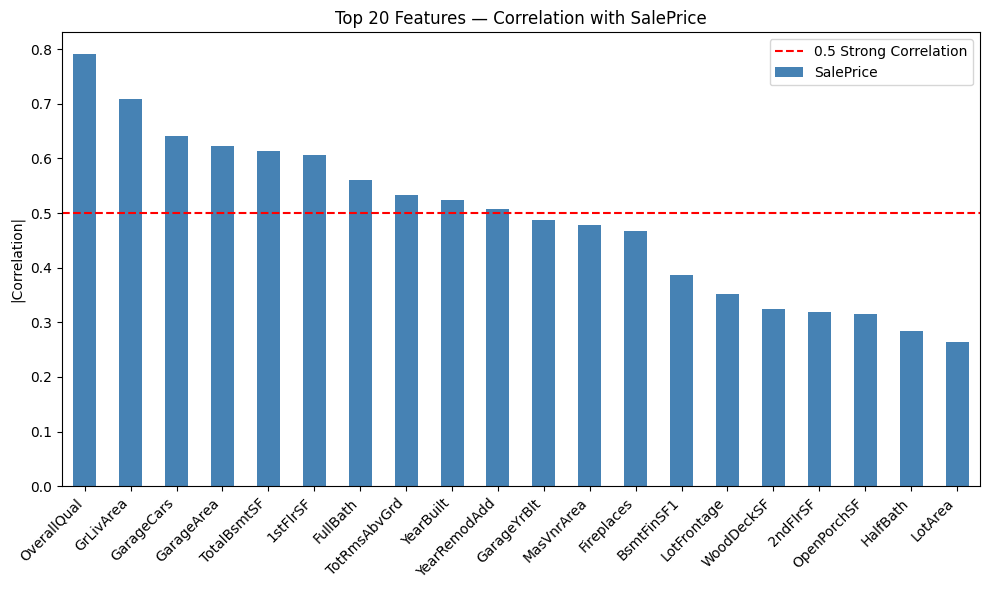

In [11]:
# Correlation SalePrice-თან
numeric_train = train.select_dtypes(include=[np.number])
corr_with_price = numeric_train.corr()['SalePrice'].abs().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
corr_with_price[1:21].plot(kind='bar', color='steelblue')
plt.title('Top 20 Features — Correlation with SalePrice')
plt.ylabel('|Correlation|')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.5, color='red', linestyle='--', label='0.5 Strong Correlation')
plt.legend()
plt.tight_layout()
plt.show()

# Data Cleaning

EDA-ის შედეგებზე დაყრდნობით:

**გადაწყვეტილებები:**
- 80%+ ცარიელი სვეტები იშლება (PoolQC, MiscFeature, Alley, Fence)
- Numeric სვეტები → **Median** (outlier-ების გამო Mean ამახინჯებს — EDA-ში ვნახეთ)
- Categorical სვეტები → **Mode** (ყველაზე გავრცელებული კატეგორია)
- LotFrontage → **Neighborhood median** (ერთი უბნის სახლებს მსგავსი ქუჩის სიგრძე აქვთ)

In [12]:
# მიდგომა 1 — Naive: ყველაფერს median/mode, არაფერს შლის
def clean_naive(df):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    return df

train_s1 = clean_naive(train)
test_s1 = clean_naive(test)
print('მიდგომა 1 — Naive')
print('Missing values:', train_s1.isnull().sum().sum())
print('Shape:', train_s1.shape)
print('პრობლემა: PoolQC (99.5% ცარიელი) mode-ით შეივსო.')
print('1453 სახლში ეს სვეტი ცარიელია — mode არარეალური მნიშვნელობაა!')

მიდგომა 1 — Naive
Missing values: 0
Shape: (1460, 81)
პრობლემა: PoolQC (99.5% ცარიელი) mode-ით შეივსო.
1453 სახლში ეს სვეტი ცარიელია — mode არარეალური მნიშვნელობაა!


In [13]:
# მიდგომა 2 — Drop 80%+ then global median/mode
def clean_drop_global(df):
    df = df.copy()
    cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    return df

train_s2 = clean_drop_global(train)
test_s2 = clean_drop_global(test)
print('მიდგომა 2 — Drop 80%+ + Global Median/Mode')
print('Missing values:', train_s2.isnull().sum().sum())
print('Shape:', train_s2.shape)
print('წაშლილი სვეტები:', train.shape[1] - train_s2.shape[1])
print('LotFrontage global median-ით შეივსო — კარგია, მაგრამ შეიძლება უკეთესიც')

მიდგომა 2 — Drop 80%+ + Global Median/Mode
Missing values: 0
Shape: (1460, 77)
წაშლილი სვეტები: 4
LotFrontage global median-ით შეივსო — კარგია, მაგრამ შეიძლება უკეთესიც


In [14]:
# მიდგომა 3 — Drop 80%+ then Neighborhood-based LotFrontage
def clean_smart(df):
    df = df.copy()
    # 80%+ ცარიელი სვეტები
    cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    # LotFrontage — Neighborhood median (ლოგიკური: ერთი უბანი = მსგავსი ქუჩა)
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()))
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
    # Numeric — median (outlier-ების გამო)
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    # Categorical — mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    return df

train_s3 = clean_smart(train)
test_s3 = clean_smart(test)
print('მიდგომა 3 — Smart (Neighborhood LotFrontage) ✅ საუკეთესო')
print('Missing values:', train_s3.isnull().sum().sum())
print('Shape:', train_s3.shape)
print('LotFrontage შეივსო Neighborhood median-ით — უფრო ზუსტი!')

მიდგომა 3 — Smart (Neighborhood LotFrontage) ✅ საუკეთესო
Missing values: 0
Shape: (1460, 77)
LotFrontage შეივსო Neighborhood median-ით — უფრო ზუსტი!


# Feature Engineering

## კატეგორიული ცვლადების რიცხვითში გადაყვანა

მოდელი მხოლოდ რიცხვებზე მუშაობს. 39 კატეგორიული სვეტი გვაქვს.

**ორი მიდგომა გამოვტესტეთ:**

1. **Label Encoding** — `CollgCr → 0`, `Veenker → 1`, `Crawfor → 2`
2. **One-Hot Encoding** — თითოეული კატეგორია ხდება ცალკე 0/1 სვეტი

**რატომ Label Encoding გავიმარჯვებინეთ — იხილეთ ქვემოთ.**

In [15]:
# Label Encoding
def encode_label(df):
    df = df.copy()
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    return df

train_le = encode_label(train_s3)
test_le = encode_label(test_s3)
print('Label Encoding:')
print('Shape:', train_le.shape)
print('სვეტების რაოდენობა არ შეცვლილა!')

Label Encoding:
Shape: (1460, 77)
სვეტების რაოდენობა არ შეცვლილა!


In [16]:
# One-Hot Encoding
def encode_onehot(df_train, df_test):
    df_train = df_train.copy()
    df_test = df_test.copy()
    cat_cols = df_train.select_dtypes(include=['object']).columns
    df_train = pd.get_dummies(df_train, columns=cat_cols)
    df_test = pd.get_dummies(df_test, columns=cat_cols)
    df_test = df_test.reindex(columns=df_train.columns, fill_value=0)
    return df_train, df_test

train_ohe, test_ohe = encode_onehot(train_s3, test_s3)
print('One-Hot Encoding:')
print('Train shape:', train_ohe.shape)
print(f'სვეტები: {train_s3.shape[1]} -> {train_ohe.shape[1]} (+{train_ohe.shape[1]-train_s3.shape[1]} სვეტი!)')

One-Hot Encoding:
Train shape: (1460, 276)
სვეტები: 77 -> 276 (+199 სვეტი!)


In [17]:
# გადაწყვეტილება: Label Encoding ✅
print('Label Encoding vs One-Hot Encoding:')
print('=' * 60)
print(f'Label Encoding:    {train_le.shape[1]} სვეტი')
print(f'One-Hot Encoding:  {train_ohe.shape[1]} სვეტი (+{train_ohe.shape[1]-train_le.shape[1]})')
print()
print('რატომ Label Encoding ✅:')
print('1. ვიყენებთ ხის მოდელებს (RF, XGBoost, GBM, LightGBM)')
print('   ხის მოდელები Label Encoding-ს კარგად ართმევს თავს')
print('   ისინი split-ებს ირჩევენ — რიცხვების "სიდიდე" არ ამახინჯებს')
print('2. OHE 179 სვეტს ქმნის — ეს ხმაურია მოდელისთვის')
print('3. OHE sparse მატრიცაა (ძირითადად 0-ები) — overfitting-ის რისკი')
print('4. Label Encoding 80 სვეტია — სუფთა, სწრაფი, ეფექტური')

Label Encoding vs One-Hot Encoding:
Label Encoding:    77 სვეტი
One-Hot Encoding:  276 სვეტი (+199)

რატომ Label Encoding ✅:
1. ვიყენებთ ხის მოდელებს (RF, XGBoost, GBM, LightGBM)
   ხის მოდელები Label Encoding-ს კარგად ართმევს თავს
   ისინი split-ებს ირჩევენ — რიცხვების "სიდიდე" არ ამახინჯებს
2. OHE 179 სვეტს ქმნის — ეს ხმაურია მოდელისთვის
3. OHE sparse მატრიცაა (ძირითადად 0-ები) — overfitting-ის რისკი
4. Label Encoding 80 სვეტია — სუფთა, სწრაფი, ეფექტური


## ახალი Feature: QualxSF (Interaction Feature)

სახლის ხარისხი (`OverallQual`) და საერთო ფართობი (`GrLivArea`) ცალ-ცალკე მნიშვნელოვანი feature-ებია, 
მაგრამ მათი **ნამრავლი** კიდევ უფრო ძლიერ სიგნალს იძლევა: 
დიდი და ხარისხიანი სახლი ბევრად ძვირია ვიდრე უბრალოდ დიდი ან უბრალოდ ხარისხიანი. 
ამ ინტერაქციის feature-ს ვამატებთ label-encoded მონაცემებს.

In [18]:
def add_features(df):
    df = df.copy()
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['QualxSF'] = df['OverallQual'] * df['TotalSF']
    return df

train_s3 = add_features(train_s3)
test_s3 = add_features(test_s3)
print("ახალი features დამატებულია!")
print("Shape:", train_s3.shape)

corr_qual = train_s3['OverallQual'].corr(train_s3['SalePrice'])
corr_sf = train_s3['TotalSF'].corr(train_s3['SalePrice'])
corr_new = train_s3['QualxSF'].corr(train_s3['SalePrice'])
print(f'\nკორელაცია SalePrice-თან:')
print(f'  OverallQual:  {corr_qual:.4f}')
print(f'  TotalSF:      {corr_sf:.4f}')
print(f'  QualxSF:      {corr_new:.4f} <-- უფრო ძლიერი კავშირი!')

ახალი features დამატებულია!
Shape: (1460, 80)

კორელაცია SalePrice-თან:
  OverallQual:  0.7910
  TotalSF:      0.7823
  QualxSF:      0.8561 <-- უფრო ძლიერი კავშირი!


# Feature Selection

ყველა feature თანაბრად სასარგებლო არ არის. ვნახოთ რომელია მნიშვნელოვანი.

In [19]:
train_le = encode_label(train_s3)
test_le = encode_label(test_s3)

X = train_le.drop(columns=['SalePrice', 'Id'])
y = np.log1p(train_le['SalePrice'])
X_test_base = test_le.drop(columns=['Id'])
X_test_base = X_test_base.reindex(columns=X.columns, fill_value=0)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (1460, 78)
y shape: (1460,)


In [20]:
# მიდგომა 1 — ყველა feature
X_all = X.copy()
X_test_all = X_test_base.copy()
print('მიდგომა 1 — ყველა feature:', X_all.shape[1])
print('პრობლემა: ბევრი სუსტი feature ხმაურს მატებს მოდელს')

მიდგომა 1 — ყველა feature: 78
პრობლემა: ბევრი სუსტი feature ხმაურს მატებს მოდელს


In [22]:
#  Correlation > 0.3
corr = train_le.corr()['SalePrice'].abs().sort_values(ascending=False)
top_corr_features = corr[corr > 0.3].index.tolist()
top_corr_features = [f for f in top_corr_features if f not in ['SalePrice', 'Id']]
X_corr = X[top_corr_features]
X_test_corr = X_test_base[top_corr_features]
print('მიდგომა 2 — Correlation > 0.3:', len(top_corr_features), 'feature')
print('Top 10:', top_corr_features[:10])
print('პრობლემა: მხოლოდ წრფივ კავშირებს ზომავს')

მიდგომა 2 — Correlation > 0.3: 29 feature
Top 10: ['QualxSF', 'OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'ExterQual', 'GarageArea', 'BsmtQual', 'TotalBsmtSF', '1stFlrSF']
პრობლემა: მხოლოდ წრფივ კავშირებს ზომავს


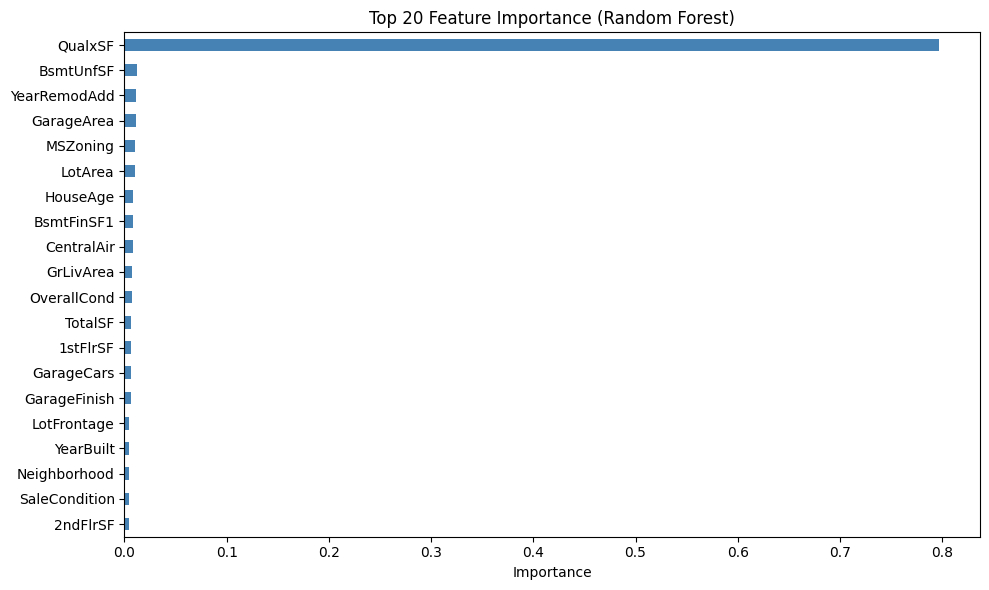

მიდგომა 3 — RF top 25: 25 feature
Features: ['QualxSF', 'BsmtUnfSF', 'YearRemodAdd', 'GarageArea', 'MSZoning', 'LotArea', 'HouseAge', 'BsmtFinSF1', 'CentralAir', 'GrLivArea', 'OverallCond', 'TotalSF', '1stFlrSF', 'GarageCars', 'GarageFinish', 'LotFrontage', 'YearBuilt', 'Neighborhood', 'SaleCondition', '2ndFlrSF', 'TotalBsmtSF', 'OpenPorchSF', 'KitchenQual', 'GarageYrBlt', 'WoodDeckSF']


In [23]:
#  Random Forest Importance top 25
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X, y)
importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances[:20].plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_rf_features = importances[:25].index.tolist()
X_rf = X[top_rf_features]
X_test_rf = X_test_base[top_rf_features]
print('მიდგომა 3 — RF top 25:', len(top_rf_features), 'feature')
print('Features:', top_rf_features)

In [24]:
# შევადაროთ სხვადასხვა რაოდენობის features
from sklearn.model_selection import cross_val_score

rf_test = RandomForestRegressor(n_estimators=100, random_state=42)

for n in [10, 15, 20, 25, 30]:
    top_n = importances[:n].index.tolist()
    X_n = X[top_n]
    scores = cross_val_score(rf_test, X_n, y, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores).mean()
    print(f'Top {n} features: CV RMSE = {rmse:.4f}')

Top 10 features: CV RMSE = 0.1442
Top 15 features: CV RMSE = 0.1408
Top 20 features: CV RMSE = 0.1389
Top 25 features: CV RMSE = 0.1399
Top 30 features: CV RMSE = 0.1405


# Training

ვტესტავთ 14 მოდელს RF top 15 features-ზე.
ყველა run იწერება MLflow-ზე: cv_rmse, train_rmse, overfit_gap.

In [25]:
def evaluate_model(model, X_tr, y_tr, run_name, params={}):
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5,
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores).mean()
    cv_std = np.sqrt(-cv_scores).std()
    model.fit(X_tr, y_tr)
    train_rmse = np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        mlflow.log_metric('cv_rmse', cv_rmse)
        mlflow.log_metric('cv_std', cv_std)
        mlflow.log_metric('train_rmse', train_rmse)
        mlflow.log_metric('overfit_gap', cv_rmse - train_rmse)
        mlflow.sklearn.log_model(model, 'model')
    print(f'{run_name}')
    print(f'  CV RMSE:    {cv_rmse:.4f} (+/- {cv_std:.4f})')
    print(f'  Train RMSE: {train_rmse:.4f}')
    print(f'  Gap:        {cv_rmse - train_rmse:.4f}')
    print()
    return model, cv_rmse, train_rmse

In [26]:
results = {}

# =============================================
# 1. LINEAR MODELS — მოველოდებით UNDERFIT-ს
# მიზეზი: სახლის ფასი არაწრფივია
# =============================================

# Ridge — სხვადასხვა regularization
for alpha in [0.01, 1.0, 100.0]:
    model, cv, tr = evaluate_model(
        Ridge(alpha=alpha), X_rf, y,
        f'Ridge_alpha{alpha}',
        {'model': 'Ridge', 'alpha': alpha, 'features': 'rf_top20'})
    results[f'Ridge_alpha{alpha}'] = {'cv_rmse': cv, 'train_rmse': tr}

# Lasso
model, cv, tr = evaluate_model(
    Lasso(alpha=0.001), X_rf, y, 'Lasso',
    {'model': 'Lasso', 'alpha': 0.001, 'features': 'rf_top20'})
results['Lasso'] = {'cv_rmse': cv, 'train_rmse': tr}

# ElasticNet
model, cv, tr = evaluate_model(
    ElasticNet(alpha=0.001, l1_ratio=0.5), X_rf, y, 'ElasticNet',
    {'model': 'ElasticNet', 'alpha': 0.001, 'features': 'rf_top20'})
results['ElasticNet'] = {'cv_rmse': cv, 'train_rmse': tr}

# BayesianRidge
model, cv, tr = evaluate_model(
    BayesianRidge(), X_rf, y, 'BayesianRidge',
    {'model': 'BayesianRidge', 'features': 'rf_top20'})
results['BayesianRidge'] = {'cv_rmse': cv, 'train_rmse': tr}

# =============================================
# 2. DECISION TREE — overfit და underfit ნათლად
# =============================================

# Underfit — ძალიან მარტივი
model, cv, tr = evaluate_model(
    DecisionTreeRegressor(max_depth=2, random_state=42), X_rf, y,
    'DecisionTree_underfit',
    {'model': 'DecisionTree', 'max_depth': 2, 'features': 'rf_top20'})
results['DecisionTree_underfit'] = {'cv_rmse': cv, 'train_rmse': tr}

# Balanced
model, cv, tr = evaluate_model(
    DecisionTreeRegressor(max_depth=6, random_state=42), X_rf, y,
    'DecisionTree_balanced',
    {'model': 'DecisionTree', 'max_depth': 6, 'features': 'rf_top20'})
results['DecisionTree_balanced'] = {'cv_rmse': cv, 'train_rmse': tr}

# Overfit — შეზღუდვა არ არის
model, cv, tr = evaluate_model(
    DecisionTreeRegressor(random_state=42), X_rf, y,
    'DecisionTree_overfit',
    {'model': 'DecisionTree', 'max_depth': 'None', 'features': 'rf_top20'})
results['DecisionTree_overfit'] = {'cv_rmse': cv, 'train_rmse': tr}

# =============================================
# 3. KNN — n_neighbors-ის გავლენა
# =============================================

for k in [3, 10, 30]:
    model, cv, tr = evaluate_model(
        KNeighborsRegressor(n_neighbors=k), X_rf, y,
        f'KNN_k{k}',
        {'model': 'KNN', 'n_neighbors': k, 'features': 'rf_top20'})
    results[f'KNN_k{k}'] = {'cv_rmse': cv, 'train_rmse': tr}

# =============================================
# 4. SVR
# =============================================

model, cv, tr = evaluate_model(
    Pipeline([('scaler', StandardScaler()), ('svr', SVR())]), X_rf, y,
    'SVR', {'model': 'SVR', 'features': 'rf_top20'})
results['SVR'] = {'cv_rmse': cv, 'train_rmse': tr}

# =============================================
# 5. RANDOM FOREST — depth-ის გავლენა
# =============================================

for depth in [3, 10, None]:
    model, cv, tr = evaluate_model(
        RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42), X_rf, y,
        f'RF_depth{depth}',
        {'model': 'RF', 'max_depth': str(depth), 'features': 'rf_top20'})
    results[f'RF_depth{depth}'] = {'cv_rmse': cv, 'train_rmse': tr}

# ExtraTrees
model, cv, tr = evaluate_model(
    ExtraTreesRegressor(n_estimators=100, random_state=42), X_rf, y,
    'ExtraTrees', {'model': 'ExtraTrees', 'features': 'rf_top20'})
results['ExtraTrees'] = {'cv_rmse': cv, 'train_rmse': tr}

# =============================================
# 6. BOOSTING — learning_rate-ის გავლენა
# =============================================

# GradientBoosting
for lr in [0.01, 0.05, 0.2]:
    model, cv, tr = evaluate_model(
        GradientBoostingRegressor(n_estimators=200, learning_rate=lr, random_state=42), X_rf, y,
        f'GBM_lr{lr}',
        {'model': 'GBM', 'learning_rate': lr, 'n_estimators': 200, 'features': 'rf_top20'})
    results[f'GBM_lr{lr}'] = {'cv_rmse': cv, 'train_rmse': tr}

# XGBoost
for lr in [0.01, 0.05, 0.2]:
    model, cv, tr = evaluate_model(
        XGBRegressor(n_estimators=200, learning_rate=lr, random_state=42, verbosity=0), X_rf, y,
        f'XGB_lr{lr}',
        {'model': 'XGBoost', 'learning_rate': lr, 'n_estimators': 200, 'features': 'rf_top20'})
    results[f'XGB_lr{lr}'] = {'cv_rmse': cv, 'train_rmse': tr}

# LightGBM
model, cv, tr = evaluate_model(
    LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42), X_rf, y,
    'LightGBM', {'model': 'LightGBM', 'learning_rate': 0.05, 'features': 'rf_top20'})
results['LightGBM'] = {'cv_rmse': cv, 'train_rmse': tr}

Ridge_alpha0.01
  CV RMSE:    0.1717 (+/- 0.0383)
  Train RMSE: 0.1602
  Gap:        0.0115

Ridge_alpha1.0
  CV RMSE:    0.1717 (+/- 0.0384)
  Train RMSE: 0.1602
  Gap:        0.0115

Ridge_alpha100.0
  CV RMSE:    0.1727 (+/- 0.0414)
  Train RMSE: 0.1618
  Gap:        0.0109

Lasso
  CV RMSE:    0.1718 (+/- 0.0398)
  Train RMSE: 0.1603
  Gap:        0.0115

ElasticNet
  CV RMSE:    0.1717 (+/- 0.0391)
  Train RMSE: 0.1602
  Gap:        0.0115

BayesianRidge
  CV RMSE:    0.1723 (+/- 0.0407)
  Train RMSE: 0.1605
  Gap:        0.0118

DecisionTree_underfit
  CV RMSE:    0.2213 (+/- 0.0079)
  Train RMSE: 0.2153
  Gap:        0.0061

DecisionTree_balanced
  CV RMSE:    0.1814 (+/- 0.0138)
  Train RMSE: 0.1217
  Gap:        0.0596

DecisionTree_overfit
  CV RMSE:    0.1925 (+/- 0.0103)
  Train RMSE: 0.0015
  Gap:        0.1910

KNN_k3
  CV RMSE:    0.1796 (+/- 0.0086)
  Train RMSE: 0.1229
  Gap:        0.0568

KNN_k10
  CV RMSE:    0.1722 (+/- 0.0081)
  Train RMSE: 0.1538
  Gap:        0.

KeyboardInterrupt: 

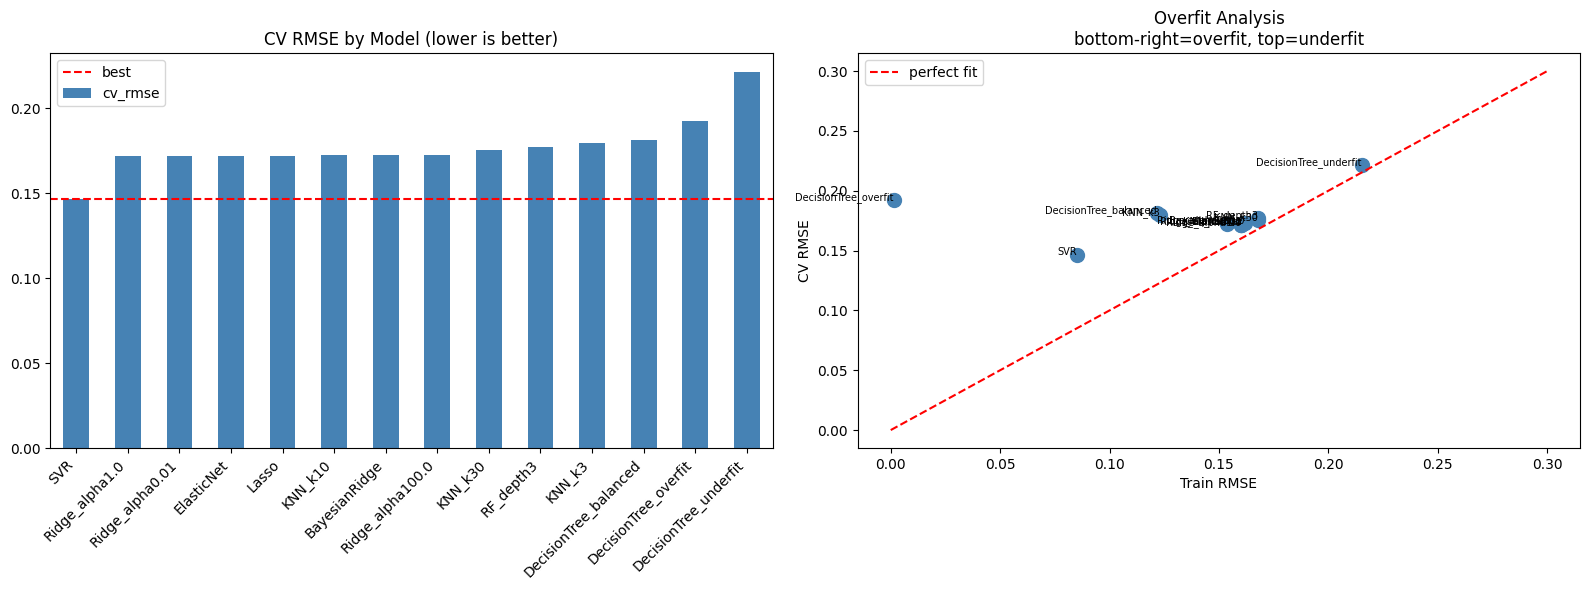

საუკეთესო მოდელი: SVR
CV RMSE: 0.1467


In [27]:
results_df = pd.DataFrame(results).T.sort_values('cv_rmse')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
results_df['cv_rmse'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('CV RMSE by Model (lower is better)')
axes[0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0].axhline(y=results_df['cv_rmse'].min(), color='red', linestyle='--', label='best')
axes[0].legend()

axes[1].scatter(results_df['train_rmse'], results_df['cv_rmse'], color='steelblue', s=100)
for i, m in enumerate(results_df.index):
    axes[1].annotate(m,
        (results_df['train_rmse'].iloc[i], results_df['cv_rmse'].iloc[i]),
        fontsize=7, ha='right')
axes[1].set_xlabel('Train RMSE')
axes[1].set_ylabel('CV RMSE')
axes[1].set_title('Overfit Analysis\nbottom-right=overfit, top=underfit')
axes[1].plot([0, 0.3], [0, 0.3], 'r--', label='perfect fit')
axes[1].legend()
plt.tight_layout()
plt.show()

print('საუკეთესო მოდელი:', results_df.index[0])
print('CV RMSE:', round(results_df['cv_rmse'].iloc[0], 4))

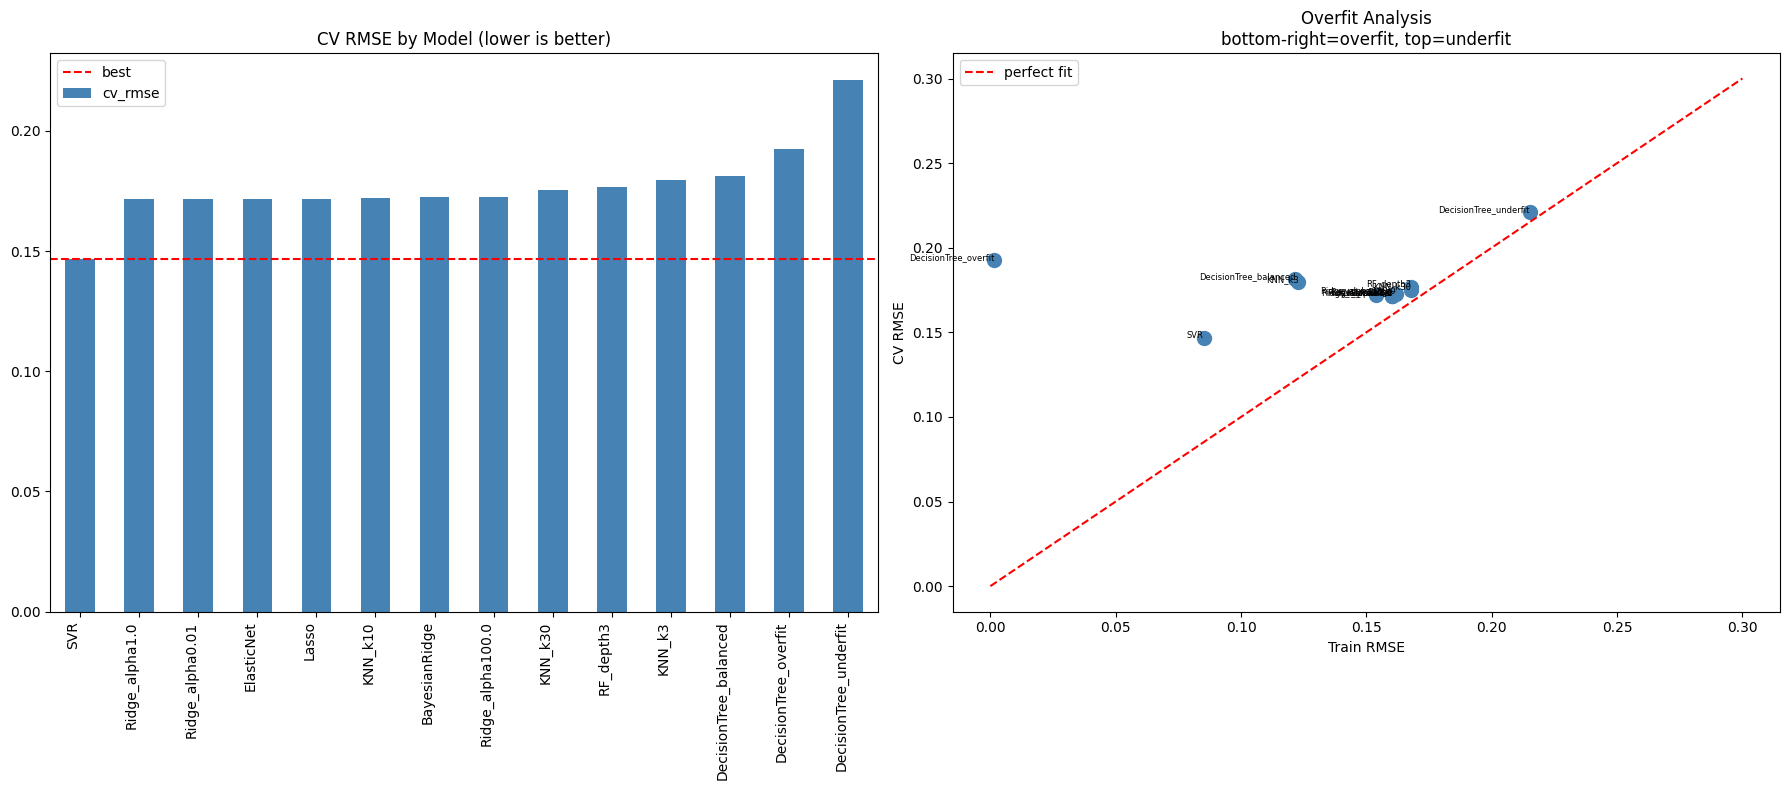


=== საუკეთესო 5 მოდელი ===
                 cv_rmse  train_rmse     gap
SVR               0.1467      0.0851  0.0616
Ridge_alpha1.0    0.1717      0.1602  0.0115
Ridge_alpha0.01   0.1717      0.1602  0.0115
ElasticNet        0.1717      0.1602  0.0115
Lasso             0.1718      0.1603  0.0115

=== ყველაზე overfit ===
                       cv_rmse  train_rmse     gap
DecisionTree_overfit    0.1925      0.0015  0.1910
SVR                     0.1467      0.0851  0.0616
DecisionTree_balanced   0.1814      0.1217  0.0596

=== ყველაზე underfit ===
                       cv_rmse  train_rmse     gap
DecisionTree_underfit   0.2213      0.2153  0.0061
RF_depth3               0.1769      0.1679  0.0090
KNN_k30                 0.1753      0.1678  0.0075

დასკვნა:
საუკეთესო მოდელი: SVR
CV RMSE: 0.1467


In [28]:
results_df = pd.DataFrame(results).T.sort_values('cv_rmse')
results_df['gap'] = results_df['cv_rmse'] - results_df['train_rmse']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

results_df['cv_rmse'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('CV RMSE by Model (lower is better)')
axes[0].set_xticklabels(results_df.index, rotation=90, ha='right')
axes[0].axhline(y=results_df['cv_rmse'].min(), color='red', linestyle='--', label='best')
axes[0].legend()

axes[1].scatter(results_df['train_rmse'], results_df['cv_rmse'], s=100, color='steelblue')
for i, m in enumerate(results_df.index):
    axes[1].annotate(m,
        (results_df['train_rmse'].iloc[i], results_df['cv_rmse'].iloc[i]),
        fontsize=6, ha='right')
axes[1].set_xlabel('Train RMSE')
axes[1].set_ylabel('CV RMSE')
axes[1].set_title('Overfit Analysis\nbottom-right=overfit, top=underfit')
axes[1].plot([0, 0.3], [0, 0.3], 'r--', label='perfect fit')
axes[1].legend()
plt.tight_layout()
plt.show()

print('\n=== საუკეთესო 5 მოდელი ===')
print(results_df[['cv_rmse', 'train_rmse', 'gap']].head(5).round(4))

print('\n=== ყველაზე overfit ===')
print(results_df[['cv_rmse', 'train_rmse', 'gap']].sort_values('gap', ascending=False).head(3).round(4))

print('\n=== ყველაზე underfit ===')
underfit = results_df[results_df['gap'] < 0.02].sort_values('cv_rmse', ascending=False)
print(underfit[['cv_rmse', 'train_rmse', 'gap']].head(3).round(4))

print('\nდასკვნა:')
print(f'საუკეთესო მოდელი: {results_df.index[0]}')
print(f'CV RMSE: {results_df["cv_rmse"].iloc[0]:.4f}')

# Hyperparameter Tuning

In [29]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
}
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid, cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_rf, y)
best_params = grid_search.best_params_
best_score = np.sqrt(-grid_search.best_score_)
print('საუკეთესო პარამეტრები:', best_params)
print('საუკეთესო CV RMSE:', round(best_score, 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits


KeyboardInterrupt: 

In [ ]:
best_model = GradientBoostingRegressor(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    random_state=42
)
best_model.fit(X_rf, y)
train_pred = best_model.predict(X_rf)
train_rmse = np.sqrt(mean_squared_error(y, train_pred))

with mlflow.start_run(run_name='GradientBoosting_best') as run:
    mlflow.log_params(best_params)
    mlflow.log_metric('cv_rmse', best_score)
    mlflow.log_metric('train_rmse', train_rmse)
    mlflow.log_metric('overfit_gap', best_score - train_rmse)
    mlflow.sklearn.log_model(
        best_model, 'model',
        registered_model_name='house-prices-best-model'
    )
    print('Run ID:', run.info.run_id)
    print('CV RMSE:', round(best_score, 4))
    print('Train RMSE:', round(train_rmse, 4))
    print('მოდელი დარეგისტრირდა Model Registry-ში!')